In [5]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit


### Variable

In [2]:
dim = 100
I = 1 # A
hx = 1 # pas spatial
hy = 1 # pas spatial

x = np.linspace(0, dim, dim)
y = np.linspace(0, dim, dim)

xx, yy = np.meshgrid(x, y)

# demi_dist = 5

A = (98, 46)
B = (98, 54)
# M = (48, 98)
# N = (51, 98)

M = (98, 48)
N = (98, 52)


### On met une matrice de conductivité

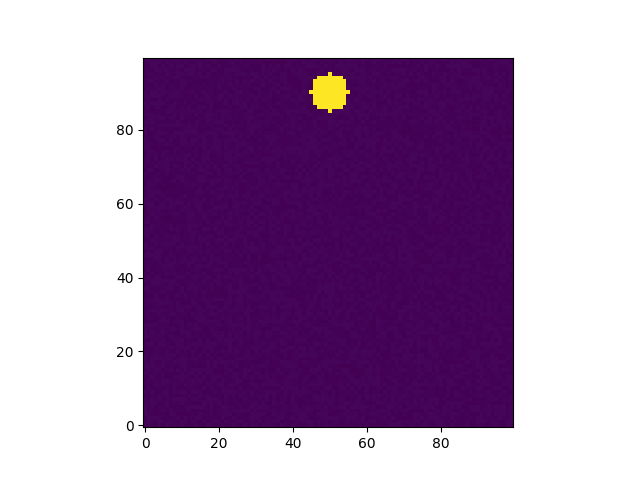

In [7]:
sigma_init = np.random.uniform(low=1, high=10, size=(dim, dim)) # np.ones((dim, dim))#

xx, yy = np.meshgrid(np.arange(dim), np.arange(dim), indexing='ij')

sigma_init[(xx-90)**2 + (yy-50)**2 <= 5**2] = 500


# sigma_init[: 81, dim//2 - 50: dim//2 + 50] = 100
pot_init = np.zeros((dim, dim))

courant_init = np.zeros((dim, dim))
courant_init[A[0]:dim, A[1]] = I
courant_init[B[0]:dim, B[1]] = -I

plt.figure()
plt.imshow(sigma_init, origin='lower')

# plt.imshow(courant_init, origin='lower')



### Calcul du potentiel

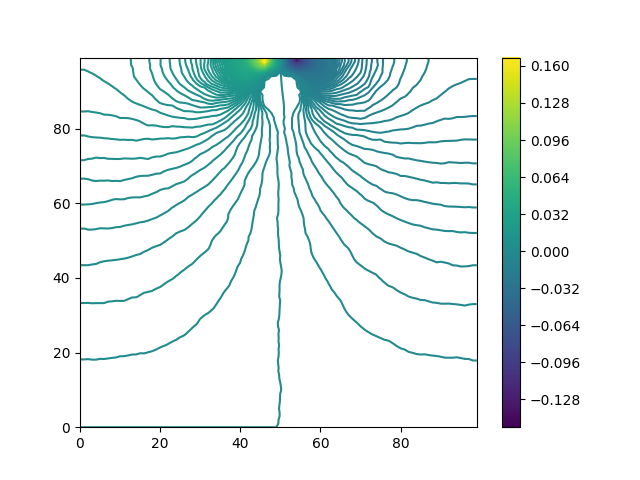

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import numba

%matplotlib widget



niter = 1000000
tol = 1e-8
error=1e10
it=0

@numba.jit
def compute_pot(V, V_k, Sigma, I):
    l = len(V[0])
    h = 1
    for i in range(1, l-1):
        for j in range(1, l-1):
            
            sigma_ifhs = (2*Sigma[j, i]*Sigma[j, i+1])/(Sigma[j, i] + Sigma[j, i+1])
            sigma_ibhs = (2*Sigma[j, i]*Sigma[j, i-1])/(Sigma[j, i] + Sigma[j, i-1])
            sigma_jfhs = (2*Sigma[j, i]*Sigma[j+1, i])/(Sigma[j, i] + Sigma[j+1, i])
            sigma_jbhs = (2*Sigma[j, i]*Sigma[j-1, i])/(Sigma[j, i] + Sigma[j-1, i])

            deno = sigma_ifhs + sigma_ibhs + sigma_jfhs + sigma_jbhs

            nom = (I[j, i]*(h**2)) + sigma_ifhs*V_k[j, i+1] + sigma_ibhs*V_k[j, i-1] + sigma_jfhs*V_k[j+1, i] + sigma_jbhs*V_k[j-1, i]

            V[j, i] = nom/deno

    return V

@numba.jit
def find_pot(V, Sigma, I, DIM, error=1e10, tol=1e-8, niter=1000000):
    it=0
    while error > tol and it < niter:
        V_k = V.copy()

        V[0, :] = 0 # haut
        V[-1, :] = V[-2, :] # bas
        V[:, 0] = V[:, 1] # gauche
        V[:, DIM-1] = V[:, DIM-2] # gauche
        #  = 0 # droite

        V = compute_pot(V, V_k, Sigma, I)

        diff = V - V_k
        error = np.sqrt(np.sum(diff**2))#np.linalg.norm(diff)

        it += 1

    return V

Voltage = find_pot(pot_init, sigma_init, courant_init, DIM=dim)

# print(f"Nombre d'itérations: {it}")
# print(f"Erreur: {error}")


plt.figure()
# plt.imshow(Voltage, origin='lower')
plt.contour(Voltage, levels=500)
# plt.imshow(pot)
plt.colorbar()
                

### Mesure de la différence de potentiel

In [9]:
def coord_schlumb(A_i, B_i, max_dist):
    A_to_move = A_i[1]
    B_to_move = B_i[1]
    A_list = []
    B_list = []
    for i in range(2, max_dist, 2):
        A = A_to_move - i
        B = B_to_move + i
        A_list.append(A)
        B_list.append(B)

    return list(zip(A_list, B_list))

c = coord_schlumb(A, B, 45)

def pot_for_schlumb(V, M, N):

    dV = V[M[0], M[1]] - V[N[0], N[1]]
    return dV


def app_res(coord_ab, dimension, cond, I):
    V_i = np.zeros((dimension, dimension))

    rho_app = []
    AB_2 = []

    for i in coord_ab:
        a, b = i
        AB_2.append(abs(b-a)/2)
        I0 = np.zeros((dimension, dimension))
        V_i = np.zeros((dimension, dimension))
        I0[98:, a]=I
        I0[98:, b]=-I

        V = find_pot(V_i, cond, I0, DIM=dimension)

        V_MN = pot_for_schlumb(V, M, N)

        # print(M, N)
        # print(a, b)

        K = np.pi * (((abs(b-a)/2)**2 - (abs(M[1]-N[1])/2)**2) / abs(M[1]-N[1]))#(2 * np.pi) / ((1/abs(a-M[1])) - (1/abs(b-M[1])) - (1/abs(a-N[1])) + (1/abs(b-N[1])))

        rho_ap = K*V_MN/I
        rho_app.append(rho_ap)

    return np.array(rho_app), np.array(AB_2)

rho_a, ab2 = app_res(c, dim, sigma_init, I)






### Résistivité apparente du sol

Text(0.5, 0, 'Demi-distance entre les électrodes [m]')

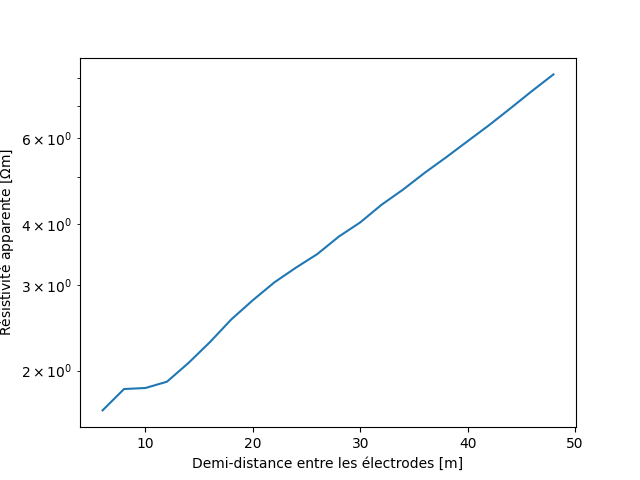

In [ ]:


plt.figure()
# plt.contourf(xx, yy, V_[0], levels=200)
plt.plot(ab2, rho_a)
plt.yscale('log')
plt.ylabel(r"Résistivité apparente [$\Omega$m]")
plt.xlabel("Demi-distance entre les électrodes [m]")

# plt.show()

### On trouve la pseudo-section

La pseudo-section est un "mapping" de la résistivité apparent du sous-sol.

In [10]:
def pseudo_section(dimension, cond, I):
    pseudo = np.zeros((dimension, dimension))

    A_i = [dimension-2, 2]
    M_i = [dimension-2, 4]
    N_i = [dimension-2, 6]
    B_i = [dimension-2, 8]

    A_i_modif = A_i.copy()
    B_i_modif = B_i.copy()
    M_i_modif = M_i.copy()
    N_i_modif = N_i.copy()

    ligne = dimension-2
    while B_i_modif[1] - A_i_modif[1] <= dimension-2:

        a, b, m, n = A_i_modif[1], B_i_modif[1], M_i_modif[1], N_i_modif[1]

        print(B_i_modif[1] - A_i_modif[1])
        print(a, m, n, b)

        I0 = np.zeros((dimension, dimension))
        V_i = np.zeros((dimension, dimension))
        
        I0[A_i_modif[0]:, A_i_modif[1]]=I
        I0[B_i_modif[0]:, B_i_modif[1]]=-I

        V = find_pot(V_i, cond, I0, DIM=dimension)

        V_MN = pot_for_schlumb(V, M_i_modif, N_i_modif)

        K = np.pi * (((abs(b-a)/2)**2 - (abs(m-n)/2)**2) / abs(m-n))
        
        centre = (m + n)//2
        pseudo[ligne, centre] = K*V_MN/I
        A_i_modif[1] += 10
        B_i_modif[1] += 10
        M_i_modif[1] += 10
        N_i_modif[1] += 10

        if B_i_modif[1] >= dimension-2:
            ligne -= 1
            A_i_modif[1] = 2
            B_i_modif[1] = B_i[1] + 8
            M_i_modif[1] = M_i[1] + 4
            N_i_modif[1] = N_i[1] + 4
            A_i[1] += 4
            B_i[1] += 8
            M_i[1] += 4
            N_i[1] += 4
            # M_i_modif[1] += 1
            # N_i_modif[1] += 1

    return pseudo

In [ ]:
pseudo_section_array = pseudo_section(dim, sigma_init, I)
# plt.imshow(pseudo_section_array)

6
2 4 6 8
6
12 14 16 18
6
22 24 26 28
6
32 34 36 38
6
42 44 46 48
6
52 54 56 58
6
62 64 66 68
6
72 74 76 78
6
82 84 86 88
14
2 8 10 16
14
12 18 20 26
14
22 28 30 36
14
32 38 40 46
14
42 48 50 56
14
52 58 60 66
14
62 68 70 76
14
72 78 80 86
14
82 88 90 96
22
2 12 14 24
22
12 22 24 34
22
22 32 34 44
22
32 42 44 54
22
42 52 54 64
22
52 62 64 74
22
62 72 74 84
22
72 82 84 94
30
2 16 18 32
30
12 26 28 42
30
22 36 38 52
30
32 46 48 62
30
42 56 58 72
30
52 66 68 82
30
62 76 78 92
38
2 20 22 40
38
12 30 32 50
38
22 40 42 60
38
32 50 52 70
38
42 60 62 80
38
52 70 72 90
46
2 24 26 48
46
12 34 36 58
46
22 44 46 68
46
32 54 56 78
46
42 64 66 88
54
2 28 30 56
54
12 38 40 66
54
22 48 50 76
54
32 58 60 86


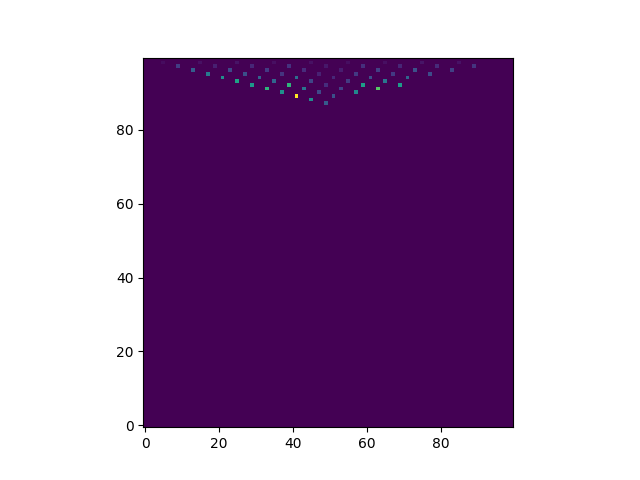

In [ ]:
plt.figure()
plt.imshow(pseudo_section_array, origin='lower')
plt.show()